# Mineria de datos - clase 4
### Alumno: Enzo Ariel Melián

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Creacion del DataFrame
df = pd.DataFrame({
"Cliente":
 [1, 2, 3, 4, 5, 6, 7, 8],
"Edad":
 [25, 40, 35, 50, 30, 45, 38, 29],
"Ingresos":
 [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
"Experiencia": [2, 10, 7, 15, 3, 20, 12, 4],
"Estado de cuenta": ["Pagado", "Moroso", "Pagado", "Moroso", "Pagado", "Moroso" ,"Pagado", "Pagado"]
})

-----

1. Análisis exploratorio de datos (EDA)

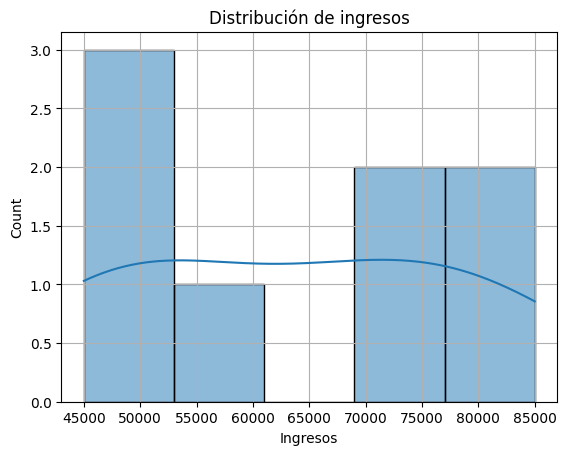

In [ ]:
#Generar histogramas de Edad e Ingresos.
sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución de ingresos")
plt.grid(True)
plt.show()

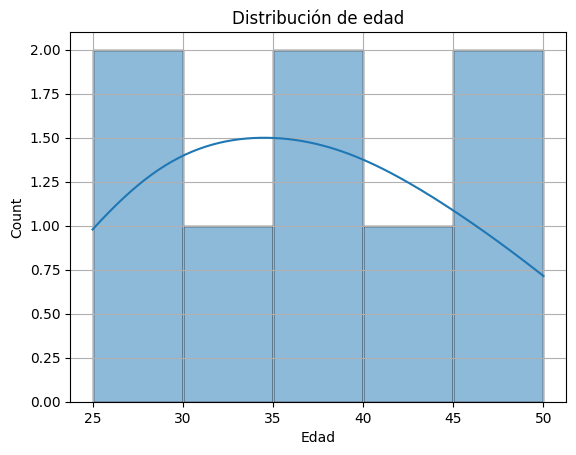

In [ ]:
#Generar histograma de Ingresos
sns.histplot(df["Edad"], bins=5, kde=True)
plt.grid(True)
plt.title("Distribución de edad")
plt.show()

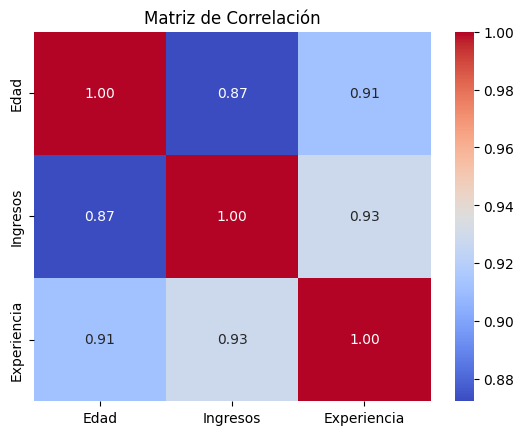

In [ ]:
#Calcular la correlación entre Edad, Ingresos y Experiencia.
df_filtrado = df[['Edad', 'Ingresos', 'Experiencia']]
sns.heatmap(df_filtrado.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

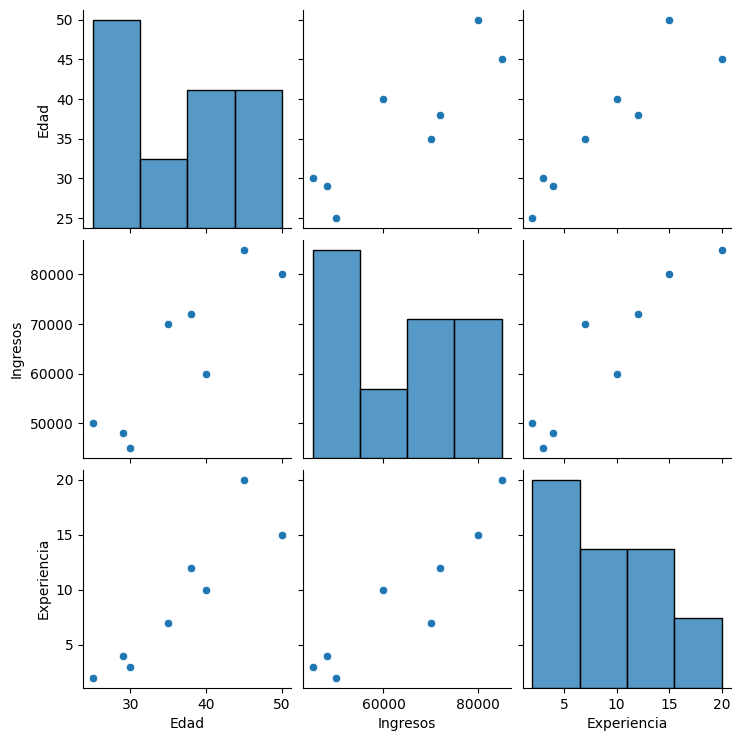

In [ ]:
#Visualizar relaciones con diagramas de dispersión.
X = df.drop(columns=['Cliente', 'Estado de cuenta'])
sns.pairplot(X)
plt.show()

-----

2. Aplicación de PCA para Reducción de Dimensionalidad

In [ ]:
# Normalizar los datos (Crucial para PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[["Edad", "Ingresos", "Experiencia"]])

In [ ]:
# Calcular varianza explicada
pca_full = PCA()
pca_full.fit(df_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Determinar cuántas componentes explican el 90% de la varianza
num_componentes_90 = np.where(varianza_acumulada >= 0.90)[0][0] + 1
print(f"Número de componentes principales que explican el 90% de la varianza: {num_componentes_90}")

Número de componentes principales que explican el 90% de la varianza: 1


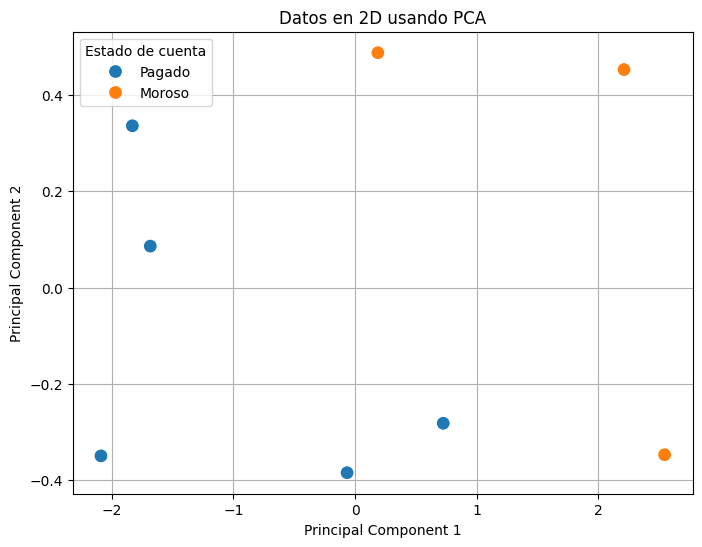

In [ ]:
# Visualizar los datos en 2D usando las dos primeras componentes principales
pca_2d = PCA(n_components=2)
df_pca = pca_2d.fit_transform(df_scaled)

df_pca_df = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca_df['Estado de cuenta'] = df['Estado de cuenta']

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Estado de cuenta', data=df_pca_df, s=100)
plt.title('Datos en 2D usando PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()



---



3. Segmentación de Clientes con Clustering



### Aplicación de K-Means Clustering

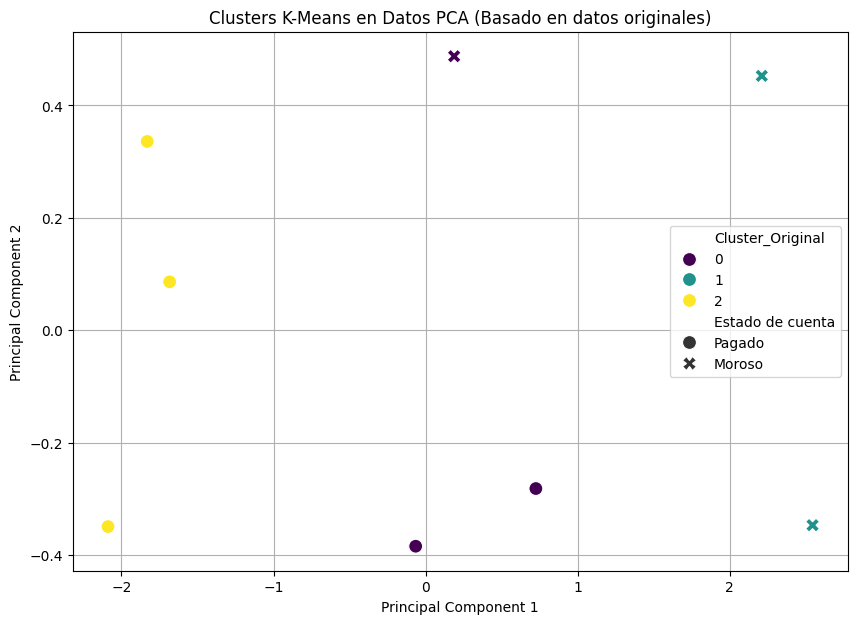

In [ ]:
# K-Means sobre los datos escalados originales
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_original = kmeans_original.fit_predict(df_scaled)
df_pca_df['Cluster_Original'] = clusters_original

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster_Original', data=df_pca_df, palette='viridis', s=100, style='Estado de cuenta')
plt.title('Clusters K-Means en Datos PCA (Basado en datos originales)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

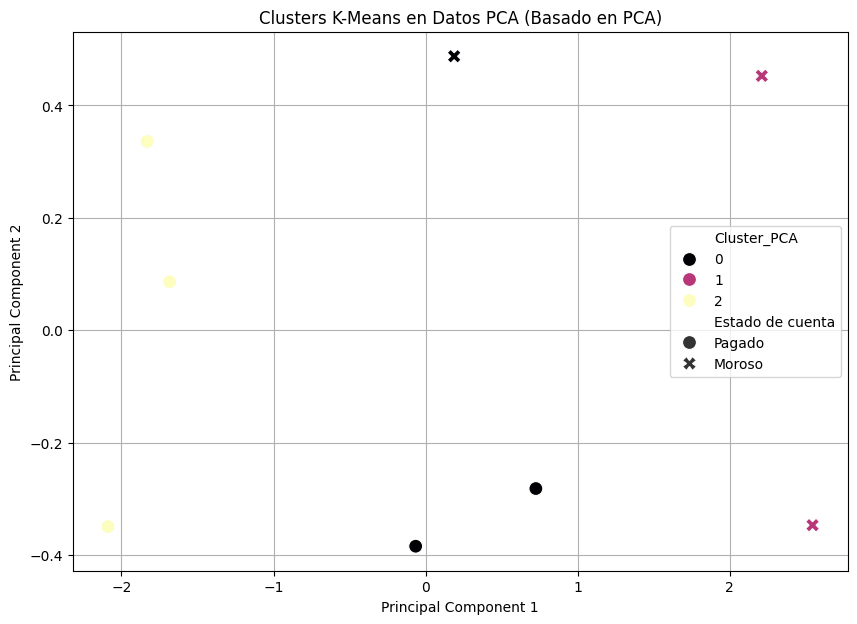

In [ ]:
# K-Means sobre los datos transformados por PCA (usando las 2 primeras componentes)
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(df_pca)
df_pca_df['Cluster_PCA'] = clusters_pca

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster_PCA', data=df_pca_df, palette='magma', s=100, style='Estado de cuenta')
plt.title('Clusters K-Means en Datos PCA (Basado en PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Comparación de los resultados de Clustering

Ahora vamos a comparar cómo se formaron los clusters cuando se aplicó K-Means a los datos originales escalados versus los datos transformados por PCA.

Podemos examinar las etiquetas de cluster asignadas a cada cliente para ver si hay diferencias significativas.

In [ ]:
comparacion_clusters = df_pca_df[['Estado de cuenta', 'Principal Component 1', 'Principal Component 2', 'Cluster_Original', 'Cluster_PCA']]
display(comparacion_clusters)

# Puedes añadir más análisis aquí, como un cross-tabulation para ver las diferencias
print('\nComparación de Asignación de Clusters (Original vs. PCA):')
display(pd.crosstab(df_pca_df['Cluster_Original'], df_pca_df['Cluster_PCA']))

,Estado de cuenta,Principal Component 1,Principal Component 2,Cluster_Original,Cluster_PCA
0,Pagado,-2.088358,-0.349258,2,2
1,Moroso,0.187607,0.487469,0,0
2,Pagado,-0.065374,-0.384217,0,0
3,Moroso,2.210591,0.452509,1,1
4,Pagado,-1.830565,0.335839,2,2
5,Moroso,2.544210,-0.346833,1,1
6,Pagado,0.724952,-0.281611,0,0
7,Pagado,-1.683062,0.086102,2,2



Comparación de Asignación de Clusters (Original vs. PCA):


Cluster_PCA,0,1,2
Cluster_Original,,,
0,3,0,0
1,0,2,0
2,0,0,3




---


#### Preguntas realizadas a Gemini

1. Tengo datos de clientes con variables de edad, ingresos y experiencia. ¿Qué técnicas avanzadas puedo usar para
mejorar la segmentación?

Rta: Además de PCA y K-Means, existen varias técnicas avanzadas que puedes explorar para mejorar la segmentación de tus clientes, considerando las variables de edad, ingresos y experiencia:

- Ingeniería de Características Avanzada:

    - Interacciones entre variables
    - Transformaciones no lineales
    - Discretización/Binning

- Algoritmos de Clustering Más Sofisticados:
    
    - DBSCAN
    - Clustering Jerárquico
    - Gaussian Mixture Models
    - Clustering por descomposición

- Reducción de Dimensionalidad Avanzada (si tuvieras más variables):
    - t-SNE
    - UMAP

Luego explicó las técnicas de interpretación de clusters y la validación de los mismos.

En cuanto a su respuesta me pareció bastante completa, en un comienzo profundizó con PCA y K-Means pero por alguna razón al volver a preguntar agregó toda esta nueva información.
